In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [3]:
def load_epoch_log(json_path):
    """
    Load a simple epoch-based training log.
    Robust to missing parameter fields or missing epoch fields.
    """
    with open(json_path, "r") as f:
        log = json.load(f)

    model_name = log.get("model", "unknown_model")
    timestamp = log.get("timestamp", "unknown_timestamp")
    params = log.get("parameters", {}) or {}  # prevent None
    epoch_data = log.get("epoch_data", []) or []  # prevent None

    rows = []
    for e in epoch_data:
        rows.append({
            "run_name": Path(json_path).stem,
            "model": model_name,
            "timestamp": timestamp,
            "epoch": e.get("epoch", None),

            # Epoch metrics (robust)
            "loss": e.get("loss", None),
            "train_acc": e.get("train_acc", None),
            "val_acc": e.get("val_acc", None),
        })

    df = pd.DataFrame(rows)
    return df, params

def load_multiple_epoch_logs(json_paths):
    dfs = []
    params_list = []

    for path in json_paths:
        df, params = load_epoch_log(path)
        df["json_file"] = path
        dfs.append(df)
        params_list.append(params)

    return dfs, params_list


def validate_epoch_alignment(dfs):
    """
    Ensure all logs have the same number of epochs.
    """
    epoch_counts = [df["epoch"].nunique() for df in dfs]
    first = epoch_counts[0]

    for i, count in enumerate(epoch_counts):
        if count != first:
            raise ValueError(
                f"Log #{i} has {count} epochs, expected {first}."
            )

    print("All logs have aligned epochs.")

import matplotlib.pyplot as plt

def plot_epoch_metric_comparison(dfs, metric, save=False):
    """
    Compare a metric (loss/train_acc/val_acc) across multiple JSON logs.
    """
    plt.figure(figsize=(8, 5))

    for df in dfs:
        run_label = df["run_name"].iloc[0]
        plt.plot(
            df["epoch"],
            df[metric],
            marker="o",
            label=run_label
        )

    plt.title(f"Comparison of {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()

    if save:
        plt.savefig(f"comparison_{metric}.png", dpi=300)

    plt.show()

def compare_epoch_logs(json_files):
    dfs, params_list = load_multiple_epoch_logs(json_files)

    # Validate structure
    validate_epoch_alignment(dfs)

    # Metrics to compare
    metrics = ["loss", "train_acc", "val_acc"]

    for m in metrics:
        plot_epoch_metric_comparison(dfs, m, save=True)

    return dfs



In [4]:
# resnet_metadata, resnet_steps, resnet_df = parse_temporal_log(r"training/logs/Temporal_ResNet50_run_20251130_101034.json")

# print("\n=== METADATA ===")
# print(resnet_metadata)

# print("\n=== STEP SUMMARY ===")
# for s in resnet_steps:
#     print(s)

# print("\n=== FIRST FEW EPOCH ROWS ===")
# print(resnet_df.head())


All logs have aligned epochs.


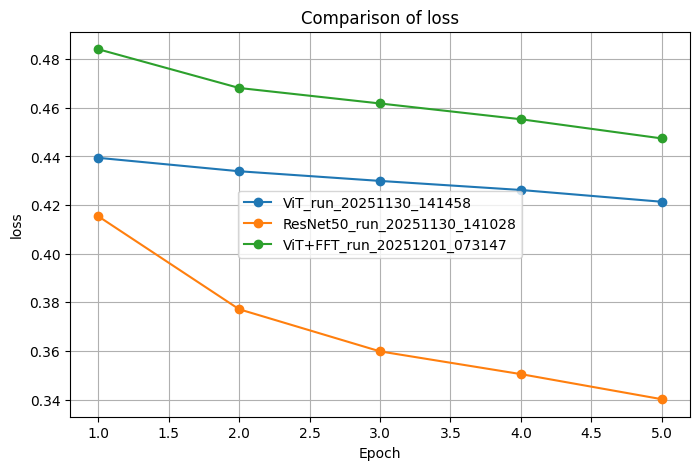

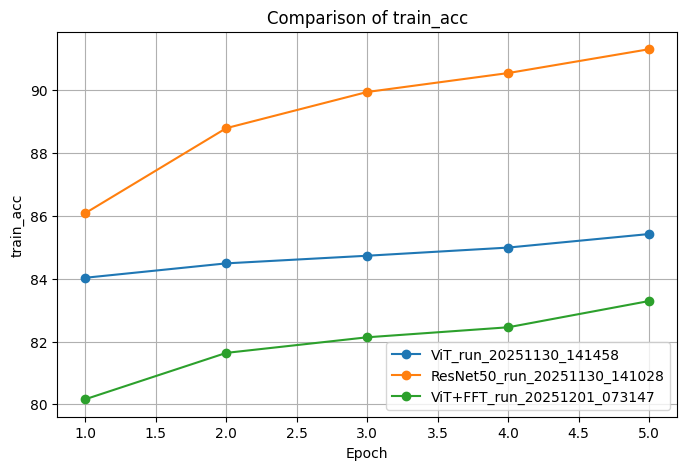

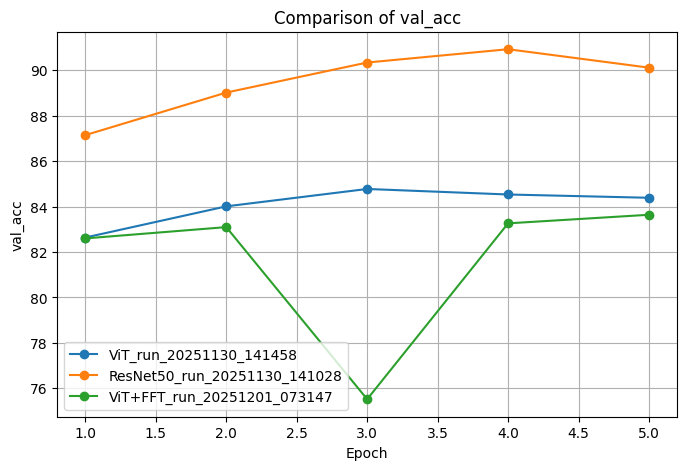

In [5]:
json_files = [
    r"training/logs/ViT_run_20251130_141458.json",
    r"training/logs/ResNet50_run_20251130_141028.json",
    r"training/logs/ViT+FFT_run_20251201_073147.json"
]

dfs = compare_epoch_logs(json_files)


### Presentation Stats

In [23]:
#### BASELINE ResNet50

import json

path = "training/logs/new_metrics/NEW_Temporal_ResNet50_run_20251201_173932.json"

with open(path) as f:
    data = json.load(f)

last_step = data["steps"][-1]
last_epoch = last_step["epochs"][-1]

acc = {k: last_epoch[k] for k in ["val_past_acc", "val_next_acc", "val_all_acc"]}
f1  = {k: last_epoch[k] for k in ["val_past_f1", "val_next_f1", "val_all_f1"]}
auc = {k: last_epoch[k] for k in ["val_past_aroc", "val_next_aroc", "val_all_aroc"]}

print("Final ACC:", acc)
print("Final F1 :", f1)
print("Final AUC:", auc)


Final ACC: {'val_past_acc': 89.27596905019998, 'val_next_acc': 87.07241226121724, 'val_all_acc': 87.29357798165137}
Final F1 : {'val_past_f1': 89.23581398648047, 'val_next_f1': 70.18970448696507, 'val_all_f1': 87.28703359193605}
Final AUC: {'val_past_aroc': 0.9586317886635702, 'val_next_aroc': 0.8414481369667719, 'val_all_aroc': 0.9443800005876819}


In [3]:
#### F1 SEEN + UNSEEN ViT Base

path = "training/logs/new_metrics/NEW_nonzero_Temporal_ViT_FFT_run_20251202_080626.json"

with open(path) as f:
    data = json.load(f)

last_step = data["steps"][-1]
last_epoch = last_step["epochs"][-1]

f1_seen  = {k: last_epoch[k] for k in ["val_past_f1", "val_next_f1", "val_all_f1"]}
f1_unseen = {k: last_epoch[k] for k in ['val_past_unseenf1', 'val_next_unseenf1', 'val_all_unseenf1']}

print("Final Seen F1 :", f1_seen)
print("Final Unseen F1:", f1_unseen)


Final Seen F1 : {'val_past_f1': 76.56439281019215, 'val_next_f1': 58.011858905402846, 'val_all_f1': 73.48467014938764}
Final Unseen F1: {'val_past_unseenf1': nan, 'val_next_unseenf1': nan, 'val_all_unseenf1': nan}


In [4]:
#### F1 SEEN ViT + FFT

path = "training/logs/new_metrics/NEW_Temporal_ViT_FFT_run_20251201_161700.json"

with open(path) as f:
    data = json.load(f)

last_step = data["steps"][-1]
last_epoch = last_step["epochs"][-1]

f1_seen  = {k: last_epoch[k] for k in ["val_past_f1", "val_next_f1", "val_all_f1"]}
f1_unseen = {k: last_epoch[k] for k in ['val_past_unseenf1', 'val_next_unseenf1', 'val_all_unseenf1']}

print("Final Seen F1 :", f1_seen)
print("Final Unseen F1:", f1_unseen)

Final Seen F1 : {'val_past_f1': 81.17373268839484, 'val_next_f1': 60.74927318750628, 'val_all_f1': 78.33487489996371}
Final Unseen F1: {'val_past_unseenf1': nan, 'val_next_unseenf1': nan, 'val_all_unseenf1': nan}
